# Notebook 2 — SMOTE + AdaBoost + RF / MLP / LightGBM
## *When Machine Learning Fails — Imbalance-Aware Correction
---

**Suite du Notebook 1** : Modèles Non-Linéaires Sans Correction  
**Ce notebook** : Correction inspirée par SMOTE

###  Lien avec le Notebook 1

Le Notebook 1 a exposé le **symptôme d'échec par déséquilibre de classes** :  
→ Random Forest, MLP et LightGBM entraînés sans correction atteignent une accuracy globale acceptable (~85%) mais présentent un recall faible pour la classe minoritaire `Revenue=True`.

###  Correction proposée

on propose la combinaison :

> **SMOTE + AdaBoost + Algorithme de Classification**

- **SMOTE** : approche au niveau des données — génère des exemples synthétiques de la classe minoritaire
- **AdaBoost** : approche au niveau de l'algorithme — renforce l'attention sur les exemples difficiles
- **Classificateur** : MLP, RF, LGBM

###  Question de recherche

Appliquer une correction imbalance-aware inspirée de SMOTE + AdaBoost améliore-t-elle la détection de la classe minoritaire `Revenue=True` pour les mêmes familles de modèles non-linéaires (Random Forest, MLP, LightGBM) utilisées dans le baseline non traité ?

**Critère de succès** : amélioration de `Recall_true`, `F1_true`, et `PR_AUC` — **pas** uniquement de l'accuracy.



## 1. Installation & Imports

In [1]:
!pip install -q imbalanced-learn lightgbm

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
import io
import traceback

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

import lightgbm as lgb
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Reproductibilité globale
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(" Librairies chargées.")
print(f"   numpy          : {np.__version__}")
print(f"   pandas         : {pd.__version__}")
print(f"   lightgbm       : {lgb.__version__}")


 Librairies chargées.
   numpy          : 2.0.2
   pandas         : 2.2.2
   lightgbm       : 4.6.0


## 2. Chargement du Dataset & EDA

 L'EDA est réalisée sur le dataset complet à des fins **purement descriptives**.  
 Aucun prétraitement appris ici. Le scaler et l'encoder seront fittés **uniquement sur X_train**.

In [3]:
# ── Chargement ──────────────────────────────────────────────
df = pd.read_csv('online_shoppers_intention.csv')
print(f" Dimensions : {df.shape}")

# Suppression des doublons
dup = df.duplicated().sum()
if dup > 0:
    df.drop_duplicates(inplace=True)
    print(f"   {dup} doublons supprimés → nouvelle taille : {df.shape}")

print("\n=== Aperçu des 10 premières lignes ===")
display(df.head(10))
print(f"\n=== df.info() ===")
df.info()

 Dimensions : (12330, 18)
   125 doublons supprimés → nouvelle taille : (12205, 18)

=== Aperçu des 10 premières lignes ===


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False



=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
Index: 12205 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficT

In [4]:
# ── Statistiques & Valeurs manquantes ───────────────────────
print("=== Statistiques descriptives ===")
display(df.describe())

missing = df.isnull().sum()
print("\n=== Valeurs manquantes ===")
print(missing[missing > 0] if missing.sum() > 0 else "Aucune valeur manquante ")

# ── Distribution cible ───────────────────────────────────────
print("\n=== Distribution de Revenue ===")
rev_counts = df['Revenue'].value_counts()
print(rev_counts)
pos_rate = rev_counts[True] / len(df) * 100
print(f"\n Taux d'achat (classe positive) : {pos_rate:.1f}%")
print(f"  Ratio d'imbalance : 1:{rev_counts[False]/rev_counts[True]:.1f}")

=== Statistiques descriptives ===


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000



=== Valeurs manquantes ===
Aucune valeur manquante 

=== Distribution de Revenue ===
Revenue
False    10297
True      1908
Name: count, dtype: int64

 Taux d'achat (classe positive) : 15.6%
  Ratio d'imbalance : 1:5.4


In [5]:
# ── Taux d'achat par Month et VisitorType ────────────────────
MONTH_ORDER = ['Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
months_ok = [m for m in MONTH_ORDER if m in df['Month'].unique()]

print("=== Taux d'achat par Mois ===")
month_rate = (df.groupby('Month')['Revenue']
              .agg(['sum','count'])
              .rename(columns={'sum':'Achats','count':'Total'}))
month_rate['Taux (%)'] = (month_rate['Achats'] / month_rate['Total'] * 100).round(1)
month_rate = month_rate.reindex([m for m in months_ok if m in month_rate.index])
display(month_rate)

print("\n=== Taux d'achat par VisitorType ===")
vt_rate = (df.groupby('VisitorType')['Revenue']
           .agg(['sum','count'])
           .rename(columns={'sum':'Achats','count':'Total'}))
vt_rate['Taux (%)'] = (vt_rate['Achats'] / vt_rate['Total'] * 100).round(1)
display(vt_rate)


=== Taux d'achat par Mois ===


,Achats,Total,Taux (%)
Month,,,
Feb,3,181,1.7
Mar,192,1860,10.3
May,365,3329,11.0
Jul,66,432,15.3
Aug,76,433,17.6
Sep,86,448,19.2
Oct,115,549,20.9
Nov,760,2982,25.5
Dec,216,1706,12.7



=== Taux d'achat par VisitorType ===


,Achats,Total,Taux (%)
VisitorType,,,
New_Visitor,422,1693,24.9
Other,16,81,19.8
Returning_Visitor,1470,10431,14.1


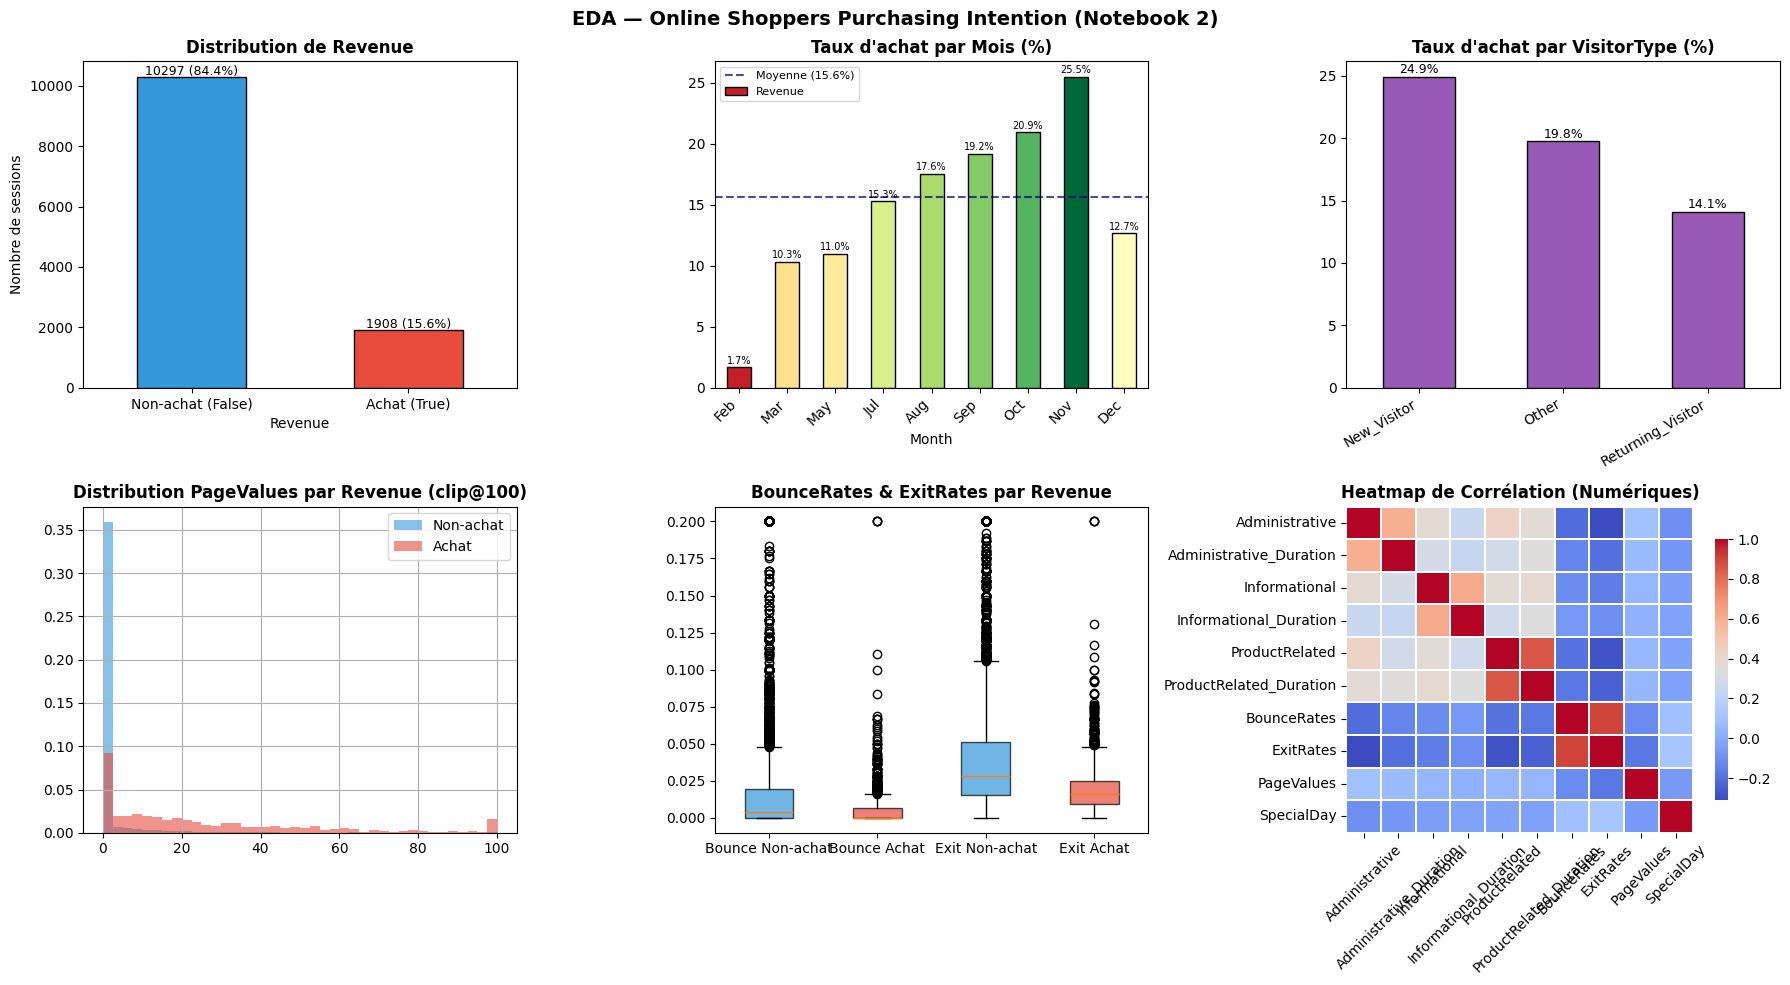

 Figure EDA sauvegardée → eda_overview_notebook2.png


In [6]:
# ── EDA — 6 Visualisations ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EDA — Online Shoppers Purchasing Intention (Notebook 2)",
             fontsize=14, fontweight='bold')

# 1. Distribution Revenue
ax = axes[0,0]
df['Revenue'].value_counts().plot(kind='bar', ax=ax,
    color=['#3498db','#e74c3c'], edgecolor='black')
ax.set_title("Distribution de Revenue", fontweight='bold')
ax.set_xticklabels(['Non-achat (False)','Achat (True)'], rotation=0)
ax.set_ylabel("Nombre de sessions")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x()+p.get_width()/2, p.get_height()+50), ha='center', fontsize=9)

# 2. Taux d'achat par Month
ax = axes[0,1]
month_rate_plot = df.groupby('Month')['Revenue'].mean().reindex(months_ok)*100
bars = month_rate_plot.plot(kind='bar', ax=ax, edgecolor='black')
cmap = plt.cm.RdYlGn(month_rate_plot.values / month_rate_plot.max())
for bar, c in zip(ax.patches, cmap):
    bar.set_facecolor(c)
ax.axhline(df['Revenue'].mean()*100, color='navy', linestyle='--', alpha=0.7,
           label=f'Moyenne ({df["Revenue"].mean()*100:.1f}%)')
ax.set_title("Taux d'achat par Mois (%)", fontweight='bold')
ax.set_xticklabels(months_ok, rotation=45, ha='right')
ax.legend(fontsize=8)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2,
                p.get_height()+0.3), ha='center', fontsize=7)

# 3. Taux d'achat par VisitorType
ax = axes[0,2]
vt_order = df.groupby('VisitorType')['Revenue'].mean().sort_values(ascending=False).index
vt_rate_plot = df.groupby('VisitorType')['Revenue'].mean().reindex(vt_order)*100
vt_rate_plot.plot(kind='bar', ax=ax, color='#9b59b6', edgecolor='black')
ax.set_title("Taux d'achat par VisitorType (%)", fontweight='bold')
ax.set_xlabel("")
ax.set_xticklabels(vt_order, rotation=30, ha='right')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x()+p.get_width()/2,
                p.get_height()+0.3), ha='center', fontsize=9)

# 4. PageValues par Revenue
ax = axes[1,0]
df[df['Revenue']==False]['PageValues'].clip(upper=100).hist(
    ax=ax, bins=40, alpha=0.6, color='#3498db', label='Non-achat', density=True)
df[df['Revenue']==True]['PageValues'].clip(upper=100).hist(
    ax=ax, bins=40, alpha=0.6, color='#e74c3c', label='Achat', density=True)
ax.set_title("Distribution PageValues par Revenue (clip@100)", fontweight='bold')
ax.legend()

# 5. BounceRates & ExitRates (boxplot)
ax = axes[1,1]
data_box = [
    df[df['Revenue']==False]['BounceRates'].clip(upper=0.2).values,
    df[df['Revenue']==True]['BounceRates'].clip(upper=0.2).values,
    df[df['Revenue']==False]['ExitRates'].clip(upper=0.3).values,
    df[df['Revenue']==True]['ExitRates'].clip(upper=0.3).values
]
bp = ax.boxplot(data_box, labels=['Bounce Non-achat','Bounce Achat','Exit Non-achat','Exit Achat'],patch_artist=True)
colors_box = ['#3498db','#e74c3c','#3498db','#e74c3c']
for patch, c in zip(bp['boxes'], colors_box):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_title("BounceRates & ExitRates par Revenue", fontweight='bold')

# 6. Heatmap
ax = axes[1,2]
num_cols = ['Administrative','Administrative_Duration','Informational',
            'Informational_Duration','ProductRelated','ProductRelated_Duration',
            'BounceRates','ExitRates','PageValues','SpecialDay']
sns.heatmap(df[num_cols].corr(), ax=ax, cmap='coolwarm', annot=False,
            linewidths=0.3, cbar_kws={'shrink':0.8})
ax.set_title("Heatmap de Corrélation (Numériques)", fontweight='bold')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_overview_notebook2.png', dpi=120, bbox_inches='tight')
plt.show()
print(" Figure EDA sauvegardée → eda_overview_notebook2.png")


###  Interprétation EDA

**Déséquilibre de classes** : environ 15.5% des sessions aboutissent à un achat. Ce déséquilibre est la cause principale du mode d'échec étudié. Un modèle naïf qui prédit systématiquement "non-achat" obtiendrait ~84.5% d'accuracy sans détecter le moindre acheteur.

**PageValues** : les sessions d'achat présentent des `PageValues` significativement plus élevées. Cette feature est le prédicteur le plus discriminant. Sa distribution fortement asymétrique justifie la transformation log1p.

**Variations saisonnières** : les taux d'achat varient selon les mois (les valeurs exactes sont calculées dans le tableau ci-dessus). Ces variations reflètent des comportements saisonniers réels, mais aussi des risques de shortcut learning si le modèle exploite Month comme raccourci.

**VisitorType** : les taux d'achat diffèrent selon le type de visiteur (calculés ci-dessus). Les visiteurs récurrents ont tendance à présenter des taux différents des nouveaux visiteurs, reflétant leur connaissance préalable du site.

 Cette EDA est **descriptive uniquement**. Aucune décision de prétraitement n'est prise ici.


## 3. Analyse des Distributions Asymétriques & Transformation log1p

Les variables comportementales web présentent une asymétrie droite prononcée (longue queue vers les grandes valeurs). La transformation `log1p(x) = log(1+x)` est appliquée pour compresser cette queue.

**Propriétés importantes** :
- Déterministe et non paramétrique (ne dépend pas de la distribution d'entraînement)
- Préserve l'ordre des valeurs
- Gère les valeurs nulles : log1p(0) = 0
- Bénéfique pour MLP (sensible à l'échelle) et SMOTE (opère dans l'espace feature)

=== Skewness avant transformation log1p ===
   Administrative_Duration             : skew = 5.59
   Informational_Duration              : skew = 7.54
   ProductRelated_Duration             : skew = 7.25
   ProductRelated                      : skew = 4.33
   PageValues                          : skew = 6.35


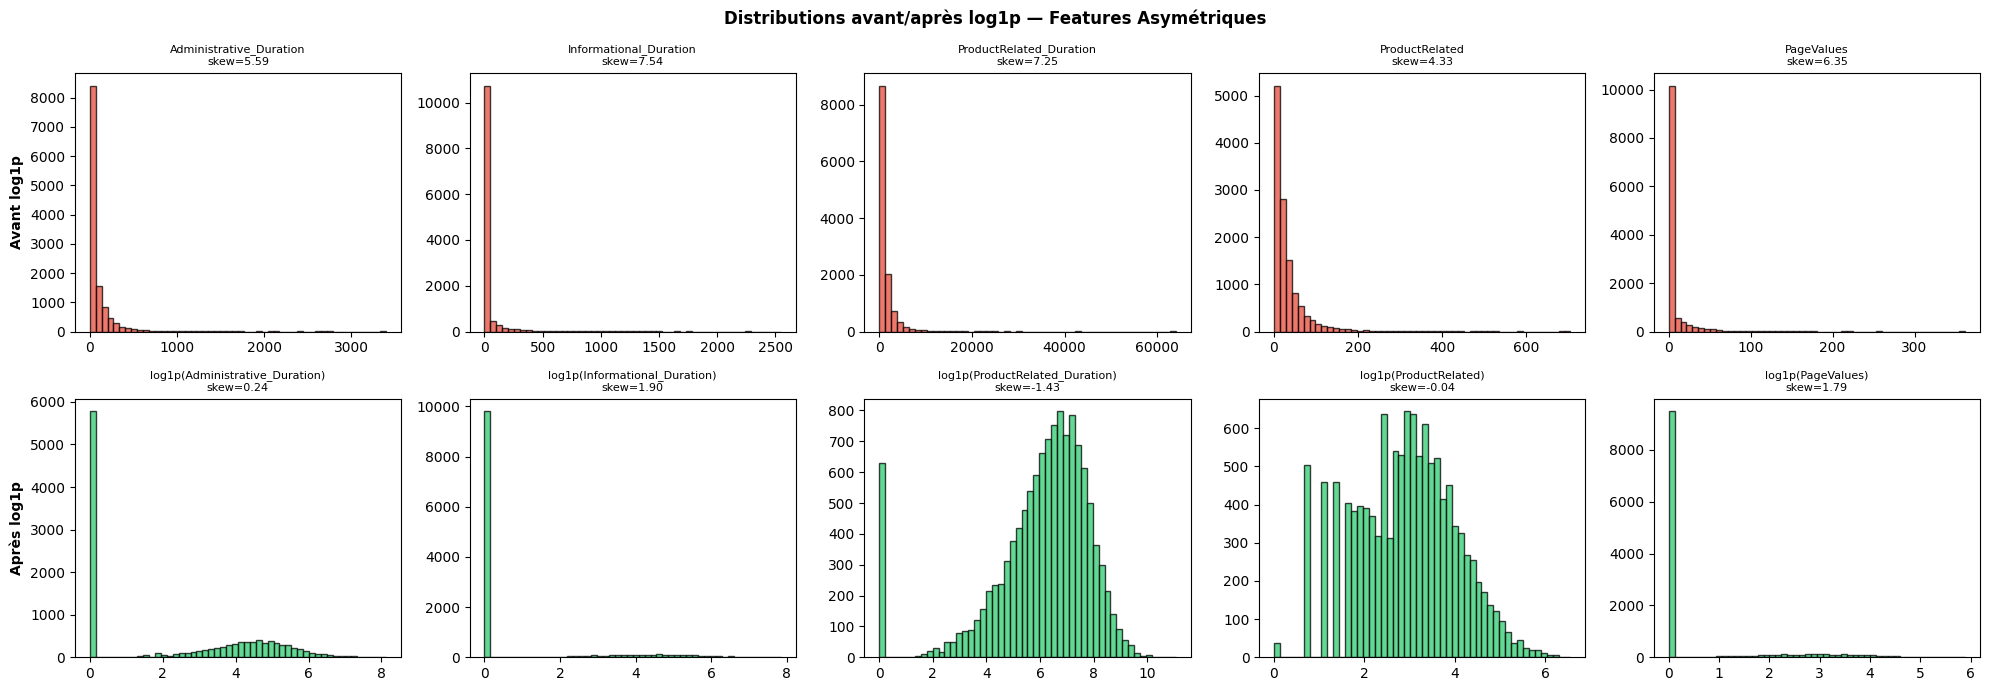

Figure sauvegardée → skewness_analysis_notebook2.png

=== Skewness après transformation log1p ===
   Administrative_Duration             : skew = 0.24
   Informational_Duration              : skew = 1.90
   ProductRelated_Duration             : skew = -1.43
   ProductRelated                      : skew = -0.04
   PageValues                          : skew = 1.79


In [7]:
# ── Analyse de la Skewness ───────────────────────────────────
LOG_FEATURES = [
    'Administrative_Duration', 'Informational_Duration',
    'ProductRelated_Duration', 'ProductRelated', 'PageValues'
]

print("=== Skewness avant transformation log1p ===")
for feat in LOG_FEATURES:
    print(f"   {feat:35s} : skew = {df[feat].skew():.2f}")

fig, axes = plt.subplots(2, len(LOG_FEATURES), figsize=(20, 7))
fig.suptitle("Distributions avant/après log1p — Features Asymétriques",
             fontsize=12, fontweight='bold')

for i, feat in enumerate(LOG_FEATURES):
    # Avant
    axes[0,i].hist(df[feat], bins=50, color='#e74c3c', alpha=0.75, edgecolor='black')
    axes[0,i].set_title(f"{feat}\nskew={df[feat].skew():.2f}", fontsize=8)
    if i == 0: axes[0,i].set_ylabel("Avant log1p", fontweight='bold')

    # Après
    log_data = np.log1p(df[feat])
    axes[1,i].hist(log_data, bins=50, color='#2ecc71', alpha=0.75, edgecolor='black')
    axes[1,i].set_title(f"log1p({feat})\nskew={log_data.skew():.2f}", fontsize=8)
    if i == 0: axes[1,i].set_ylabel("Après log1p", fontweight='bold')

plt.tight_layout()
plt.savefig('skewness_analysis_notebook2.png', dpi=120, bbox_inches='tight')
plt.show()
print("Figure sauvegardée → skewness_analysis_notebook2.png")

print("\n=== Skewness après transformation log1p ===")
for feat in LOG_FEATURES:
    print(f"   {feat:35s} : skew = {np.log1p(df[feat]).skew():.2f}")


## 4. Prétraitement & Split Anti-Fuite

### Règles d'or (identiques au Notebook 1)
1. **Split d'abord** → Train (60%) / Val (20%) / Test (20%), stratifié par Revenue
2. **log1p** appliqué avant le split (transformation déterministe, non paramétrique)
3. **StandardScaler** et **OneHotEncoder** fittés **uniquement sur X_train**
4. Val et Test transformés avec les paramètres appris sur Train
5. **SMOTE** appliqué **uniquement dans le pipeline imblearn** lors du `.fit(X_train, y_train)`

In [8]:
# ── Constantes de preprocessing ──
CAT_FEATURES = ['Month', 'VisitorType', 'Weekend']

NUM_FEATURES = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
    'OperatingSystems', 'Browser', 'Region', 'TrafficType'
]

LOG_FEATURES = [
    'Administrative_Duration', 'Informational_Duration',
    'ProductRelated_Duration', 'ProductRelated', 'PageValues'
]

# ── Conversion cible et log1p ────────────────────────────────
df['Revenue'] = df['Revenue'].astype(int)

for feat in LOG_FEATURES:
    df[feat] = np.log1p(df[feat])

print("Revenue converti en 0/1")
print(f"log1p appliqué à {len(LOG_FEATURES)} features asymétriques")


Revenue converti en 0/1
log1p appliqué à 5 features asymétriques


In [9]:
# ── Split 60 / 20 / 20 stratifié ────────────────────────────
X = df.drop(columns=['Revenue'])
y = df['Revenue']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)

print(f"Splits créés :")
print(f"Train      : {X_train.shape} | Revenue=1 : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Validation : {X_val.shape}   | Revenue=1 : {y_val.sum()} ({y_val.mean()*100:.1f}%)")
print(f" Test       : {X_test.shape}  | Revenue=1 : {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"\nLe test set est mis de côté jusqu'à l'évaluation finale.")

Splits créés :
Train      : (7323, 17) | Revenue=1 : 1145 (15.6%)
Validation : (2441, 17)   | Revenue=1 : 381 (15.6%)
 Test       : (2441, 17)  | Revenue=1 : 382 (15.6%)

Le test set est mis de côté jusqu'à l'évaluation finale.


In [10]:
# ── Préprocesseur sklearn (identique Notebook 1) ─────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(),                                       NUM_FEATURES),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
], remainder='drop')

# Fit UNIQUEMENT sur X_train
preprocessor.fit(X_train)

# Transformation des 3 sets
X_train_proc = preprocessor.transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

n_features_proc = X_train_proc.shape[1]
print(f"  Préprocesseur fitté sur X_train uniquement.")
print(f"   X_train_proc : {X_train_proc.shape}")
print(f"   X_val_proc   : {X_val_proc.shape}")
print(f"   X_test_proc  : {X_test_proc.shape}")
print(f"   Dimensions après OHE : {n_features_proc} features")

  Préprocesseur fitté sur X_train uniquement.
   X_train_proc : (7323, 29)
   X_val_proc   : (2441, 29)
   X_test_proc  : (2441, 29)
   Dimensions après OHE : 29 features


## 5. Fonctions Utilitaires

In [11]:
# ── Helpers ─────────────────────────────────────────────────

def get_model_size(model):
    """Taille mémoire via sérialisation pickle (Ko)."""""
    buf = io.BytesIO()
    pickle.dump(model, buf)
    return round(buf.tell() / 1024, 1)

def specificity_score(y_true, y_pred):
    """Spécificité = TN / (TN + FP) — taux de vrais négatifs correctement classifiés."""""
    cm = confusion_matrix(y_true, y_pred)
    tn, fp = cm[0,0], cm[0,1]
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

def evaluate_model(name, model, X, y, threshold=0.5):
    """
    Évalue un modèle sklearn ou imblearn pipeline.
    Retourne un dict avec toutes les métriques clés.
    Focus sur Revenue=True (classe positive).
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'Model'          : name,
        'Accuracy'       : accuracy_score(y, y_pred),
        'Precision_true' : precision_score(y, y_pred, zero_division=0),
        'Recall_true'    : recall_score(y, y_pred, zero_division=0),
        'Specificity'    : specificity_score(y, y_pred),
        'F1_true'        : f1_score(y, y_pred, zero_division=0),
        'ROC_AUC'        : roc_auc_score(y, y_prob),
        'PR_AUC'         : average_precision_score(y, y_prob),
    }, y_pred, y_prob

def plot_confusion_matrix(y_true, y_pred, title="", ax=None):
    """Matrice de confusion annotée."""""
    cm = confusion_matrix(y_true, y_pred)
    if ax is None: _, ax = plt.subplots(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-achat (0)','Achat (1)'],
                yticklabels=['Non-achat (0)','Achat (1)'])
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{title}\nTP={tp} FP={fp} FN={fn} TN={tn}", fontweight='bold', fontsize=9)
    ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")

def plot_roc_curve(y_true, y_prob, name, ax, color='blue', lw=2):
    """Courbe ROC."""""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, lw=lw, color=color, label=f'{name} (AUC={auc:.3f})')
    ax.plot([0,1],[0,1],'k--',alpha=0.4)
    ax.set_xlabel("Taux de Faux Positifs"); ax.set_ylabel("Recall (TPR)")
    ax.set_title("Courbe ROC"); ax.legend(fontsize=8)

def plot_pr_curve(y_true, y_prob, name, ax, color='blue', lw=2):
    """Courbe Précision-Rappel."""""
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    baseline = y_true.mean()
    ax.plot(rec, prec, lw=lw, color=color, label=f'{name} (AP={ap:.3f})')
    ax.axhline(baseline, color='gray', linestyle='--', alpha=0.5,
               label=f'Baseline aléatoire ({baseline:.2f})')
    ax.set_xlabel("Recall"); ax.set_ylabel("Précision")
    ax.set_title("Courbe Précision-Rappel"); ax.legend(fontsize=8)

print("Fonctions utilitaires définies (+ specificity_score).")


Fonctions utilitaires définies (+ specificity_score).


## 6. Modèles Baseline Sans Correction

Entraînement des 3 modèles non-linéaires **sans SMOTE** et **sans AdaBoost**, sur les données prétraitées.  
Objectif : établir la référence d'échec pour comparer avec les modèles corrigés.

In [12]:
# ── Baseline — Random Forest ─────────────────────────────────
rf_configs = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': 15,   'min_samples_leaf': 2},
    {'n_estimators': 100, 'max_depth': 10,   'min_samples_leaf': 5},
]

baseline_results = []
best_rf_model = None
best_rf_score = -1

print("── Random Forest Baseline ──────────────────────────────────")
for cfg in rf_configs:
    t0 = time.perf_counter()
    rf = RandomForestClassifier(**cfg, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_train_proc, y_train)
    t1 = time.perf_counter()

    metrics, _, _ = evaluate_model(f"Baseline RF {cfg}", rf, X_val_proc, y_val)
    metrics['train_time_s']  = round(t1-t0, 2)
    metrics['model_size_kb'] = get_model_size(rf)
    metrics['Model_Family']  = 'Random Forest'
    metrics['Pipeline']      = 'Baseline (no SMOTE)'
    metrics['AdaBoost_Status'] = 'N/A'
    metrics['Notes']         = str(cfg)
    baseline_results.append(metrics)

    if metrics['PR_AUC'] > best_rf_score:
        best_rf_score = metrics['PR_AUC']
        best_rf_model = rf
    print(f"   cfg={cfg} | Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")

print(f"\n Best RF Baseline : PR_AUC={best_rf_score:.4f}")


── Random Forest Baseline ──────────────────────────────────
   cfg={'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1} | Recall=0.543 | F1=0.626 | PR_AUC=0.721
   cfg={'n_estimators': 200, 'max_depth': 15, 'min_samples_leaf': 2} | Recall=0.535 | F1=0.624 | PR_AUC=0.735
   cfg={'n_estimators': 100, 'max_depth': 10, 'min_samples_leaf': 5} | Recall=0.530 | F1=0.631 | PR_AUC=0.739

 Best RF Baseline : PR_AUC=0.7385


In [13]:
# ── Baseline — MLP ───────────────────────────────────────────
mlp_configs = [
    {'hidden_layer_sizes': (128, 64),    'activation': 'relu', 'max_iter': 300},
    {'hidden_layer_sizes': (256,128,64), 'activation': 'relu', 'max_iter': 300},
    {'hidden_layer_sizes': (100,),       'activation': 'tanh', 'max_iter': 300},
]

best_mlp_model = None
best_mlp_score = -1

print("── MLP Baseline ─────────────────────────────────────────────")
for cfg in mlp_configs:
    t0 = time.perf_counter()
    mlp = MLPClassifier(**cfg, early_stopping=True, validation_fraction=0.1,
                         n_iter_no_change=10, random_state=RANDOM_STATE)
    mlp.fit(X_train_proc, y_train)
    t1 = time.perf_counter()

    metrics, _, _ = evaluate_model(f"Baseline MLP {cfg['hidden_layer_sizes']}", mlp, X_val_proc, y_val)
    metrics['train_time_s']  = round(t1-t0, 2)
    metrics['model_size_kb'] = get_model_size(mlp)
    metrics['Model_Family']  = 'MLP'
    metrics['Pipeline']      = 'Baseline (no SMOTE)'
    metrics['AdaBoost_Status'] = 'N/A'
    metrics['Notes']         = f"layers={cfg['hidden_layer_sizes']}"
    baseline_results.append(metrics)

    if metrics['PR_AUC'] > best_mlp_score:
        best_mlp_score = metrics['PR_AUC']
        best_mlp_model = mlp
    print(f"   cfg={cfg['hidden_layer_sizes']} | Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")

print(f"\n Best MLP Baseline : PR_AUC={best_mlp_score:.4f}")


── MLP Baseline ─────────────────────────────────────────────
   cfg=(128, 64) | Recall=0.567 | F1=0.636 | PR_AUC=0.714
   cfg=(256, 128, 64) | Recall=0.562 | F1=0.627 | PR_AUC=0.715
   cfg=(100,) | Recall=0.585 | F1=0.645 | PR_AUC=0.708

 Best MLP Baseline : PR_AUC=0.7154


In [14]:
# ── Baseline — LightGBM ──────────────────────────────────────
lgbm_configs = [
    {'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': -1},
    {'n_estimators': 300, 'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': 8},
    {'n_estimators': 200, 'learning_rate': 0.10, 'num_leaves': 31, 'max_depth': 6},
]

best_lgbm_model = None
best_lgbm_score = -1

print("── LightGBM Baseline ────────────────────────────────────────")
for cfg in lgbm_configs:
    t0 = time.perf_counter()
    lgbm = lgb.LGBMClassifier(**cfg, random_state=RANDOM_STATE, verbose=-1)
    lgbm.fit(X_train_proc, y_train,
             eval_set=[(X_val_proc, y_val)],
             callbacks=[lgb.early_stopping(50, verbose=False),
                        lgb.log_evaluation(period=-1)])
    t1 = time.perf_counter()

    metrics, _, _ = evaluate_model(f"Baseline LightGBM lr={cfg['learning_rate']}", lgbm, X_val_proc, y_val)
    metrics['train_time_s']  = round(t1-t0, 2)
    metrics['model_size_kb'] = get_model_size(lgbm)
    metrics['Model_Family']  = 'LightGBM'
    metrics['Pipeline']      = 'Baseline (no SMOTE)'
    metrics['AdaBoost_Status'] = 'N/A'
    metrics['Notes']         = f"lr={cfg['learning_rate']}, leaves={cfg['num_leaves']}"
    baseline_results.append(metrics)

    if metrics['PR_AUC'] > best_lgbm_score:
        best_lgbm_score = metrics['PR_AUC']
        best_lgbm_model = lgbm
    print(f"   cfg lr={cfg['learning_rate']} | Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")

print(f"\n Best LightGBM Baseline : PR_AUC={best_lgbm_score:.4f}")


── LightGBM Baseline ────────────────────────────────────────
   cfg lr=0.05 | Recall=0.601 | F1=0.654 | PR_AUC=0.739
   cfg lr=0.03 | Recall=0.585 | F1=0.643 | PR_AUC=0.732
   cfg lr=0.1 | Recall=0.583 | F1=0.643 | PR_AUC=0.734

 Best LightGBM Baseline : PR_AUC=0.7388


In [15]:
# ── Tableau Baseline ─────────────────────────────────────────
df_baseline = pd.DataFrame(baseline_results)[[
    'Model_Family','Notes','Accuracy','Precision_true','Recall_true',
    'Specificity','F1_true','ROC_AUC','PR_AUC','train_time_s','model_size_kb'
]]
print("=== Résultats Baseline (Validation Set) ===")
display(df_baseline.sort_values('PR_AUC', ascending=False).reset_index(drop=True))

pd.DataFrame(baseline_results).to_csv('baseline_results_notebook2.csv', index=False)
print("\n Sauvegardé → baseline_results_notebook2.csv")

=== Résultats Baseline (Validation Set) ===


,Model_Family,Notes,Accuracy,Precision_true,Recall_true,Specificity,F1_true,ROC_AUC,PR_AUC,train_time_s,model_size_kb
0,LightGBM,"lr=0.05, leaves=31",0.900860,0.717868,0.601050,0.956311,0.654286,0.926770,0.738806,0.42,242.5
1,Random Forest,"{'n_estimators': 100, 'max_depth': 10, 'min_sa...",0.903318,0.779923,0.530184,0.972330,0.631250,0.921310,0.738548,1.45,2727.3
2,Random Forest,"{'n_estimators': 200, 'max_depth': 15, 'min_sa...",0.899222,0.747253,0.535433,0.966505,0.623853,0.923070,0.734508,3.62,13923.3
3,LightGBM,"lr=0.1, leaves=31",0.898812,0.716129,0.582677,0.957282,0.642547,0.927523,0.734130,0.14,113.2
4,LightGBM,"lr=0.03, leaves=63",0.898402,0.712460,0.585302,0.956311,0.642651,0.924666,0.732238,0.55,724.3
5,Random Forest,"{'n_estimators': 100, 'max_depth': None, 'min_...",0.898812,0.739286,0.543307,0.964563,0.626324,0.917334,0.720856,1.81,10830.3
6,MLP,"layers=(256, 128, 64)",0.895535,0.708609,0.561680,0.957282,0.626647,0.925656,0.715406,7.41,1153.9
7,MLP,"layers=(128, 64)",0.898812,0.724832,0.566929,0.960194,0.636230,0.924906,0.713861,20.12,293.1
8,MLP,"layers=(100,)",0.899631,0.719355,0.585302,0.957767,0.645441,0.916862,0.708067,2.02,80.6



 Sauvegardé → baseline_results_notebook2.csv


## 7. Modèles Corrigés — SMOTE + AdaBoost + RF/MLP/LightGBM

SMOTE + AdaBoost + Algorithme de Classification

### Architecture du pipeline imblearn anti-fuite

```
ImbPipeline([
    ('preprocessor', ColumnTransformer),   ← fitté sur X_train uniquement
    ('smote',        SMOTE(k=5)),           ← appliqué sur train uniquement, JAMAIS sur val/test
    ('clf',          Classifier)            ← entraîné sur données SMOTE-rééchantillonnées
])
```

### Note sur la compatibilité AdaBoost

`AdaBoostClassifier` nécessite que son `estimator` :
1. Supporte `sample_weight` dans `.fit()`
2. Supporte `predict_proba()`
3. Soit compatible avec l'API sklearn

Certains classificateurs (MLP avec sample_weight, LightGBM dans sklearn AdaBoost) peuvent poser des problèmes. Le code ci-dessous gère chaque cas explicitement avec un fallback documenté.

In [16]:
# ── Paramètres SMOTE ─────────────────────────────────────────
SMOTE_K = 5  # nombre de voisins pour interpolation

# ── Préprocesseur (même structure que Section 4) ─────────────
# Sera intégré dans chaque ImbPipeline
def fresh_preprocessor():
    """Retourne un nouveau ColumnTransformer non fitté."""""
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(),                                        NUM_FEATURES),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_FEATURES)
    ], remainder='drop')

corrected_results = []
corrected_models  = {}

print("Construction des pipelines SMOTE + AdaBoost + Classificateur...")
print()


Construction des pipelines SMOTE + AdaBoost + Classificateur...



In [17]:
# ── A. SMOTE + AdaBoost + Random Forest ─────────────────────
# RandomForestClassifier supporte sample_weight dans .fit()
# AdaBoost wrapping est techniquement possible
# et conceptuellement non standard. On essaie, puis fallback si échec.

print("=" * 60)
print("A. SMOTE + AdaBoost + Random Forest")
print("=" * 60)

ada_rf_base = RandomForestClassifier(
    n_estimators=50,  # réduit car encapsulé dans AdaBoost
    max_depth=5,
    random_state=RANDOM_STATE, n_jobs=-1
)
ada_rf = AdaBoostClassifier(
    estimator=ada_rf_base,
    n_estimators=50,
    learning_rate=0.5,
    algorithm='SAMME',
    random_state=RANDOM_STATE
)
pipe_ada_rf = ImbPipeline([
    ('preprocessor', fresh_preprocessor()),
    ('smote',        SMOTE(k_neighbors=SMOTE_K, random_state=RANDOM_STATE)),
    ('clf',          ada_rf)
])

try:
    t0 = time.perf_counter()
    pipe_ada_rf.fit(X_train, y_train)
    t1 = time.perf_counter()

    metrics, _, _ = evaluate_model("SMOTE+AdaBoost+RF", pipe_ada_rf, X_val, y_val)
    metrics['train_time_s']  = round(t1-t0, 2)
    metrics['model_size_kb'] = get_model_size(pipe_ada_rf)
    metrics['Model_Family']  = 'Random Forest'
    metrics['Pipeline']      = 'SMOTE + AdaBoost + RF'
    metrics['AdaBoost_Status'] = 'Compatible'
    metrics['Notes']         = 'AdaBoost(n=50, lr=0.5) + RF(n=50, depth=5)'
    corrected_results.append(metrics)
    corrected_models['SMOTE+AdaBoost+RF'] = pipe_ada_rf
    print(f" Succès | Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")

except Exception as e:
    print(f" AdaBoost+RF échoué : {type(e).__name__}: {e}")
    print(f" Fallback : SMOTE + Random Forest directement")
    pipe_smote_rf = ImbPipeline([
        ('preprocessor', fresh_preprocessor()),
        ('smote',        SMOTE(k_neighbors=SMOTE_K, random_state=RANDOM_STATE)),
        ('clf',          RandomForestClassifier(n_estimators=200, max_depth=None,
                                                min_samples_leaf=2,
                                                random_state=RANDOM_STATE, n_jobs=-1))
    ])
    t0 = time.perf_counter()
    pipe_smote_rf.fit(X_train, y_train)
    t1 = time.perf_counter()
    metrics, _, _ = evaluate_model("SMOTE+RF (fallback)", pipe_smote_rf, X_val, y_val)
    metrics['train_time_s']  = round(t1-t0, 2)
    metrics['model_size_kb'] = get_model_size(pipe_smote_rf)
    metrics['Model_Family']  = 'Random Forest'
    metrics['Pipeline']      = 'SMOTE + RF (AdaBoost incompatible)'
    metrics['AdaBoost_Status'] = 'Fallback'
    metrics['Notes']         = f'AdaBoost incompatible: {type(e).__name__}'
    corrected_results.append(metrics)
    corrected_models['SMOTE+RF (fallback)'] = pipe_smote_rf
    print(f"   Fallback | Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")


A. SMOTE + AdaBoost + Random Forest
 Succès | Recall=0.575 | F1=0.615 | PR_AUC=0.673


In [18]:
# ── B. SMOTE + AdaBoost + MLP ────────────────────────────────
# MLPClassifier NE supporte PAS sample_weight dans .fit()
# AdaBoost wrapper est INCOMPATIBLE avec sklearn MLP
# Fallback documenté : SMOTE + MLP directement

print("=" * 60)
print("B. SMOTE + AdaBoost + MLP")
print("=" * 60)

print(" Test de compatibilité AdaBoost + MLP...")
mlp_base = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu',
                          max_iter=200, random_state=RANDOM_STATE)
ada_mlp = AdaBoostClassifier(
    estimator=mlp_base,
    n_estimators=10,
    algorithm='SAMME',
    random_state=RANDOM_STATE
)
pipe_ada_mlp_test = ImbPipeline([
    ('preprocessor', fresh_preprocessor()),
    ('smote',        SMOTE(k_neighbors=SMOTE_K, random_state=RANDOM_STATE)),
    ('clf',          ada_mlp)
])

try:
    # Test sur un petit sous-ensemble
    pipe_ada_mlp_test.fit(X_train.head(500), y_train.head(500))
    # Si succès
    pipe_ada_mlp_full = ImbPipeline([
        ('preprocessor', fresh_preprocessor()),
        ('smote',        SMOTE(k_neighbors=SMOTE_K, random_state=RANDOM_STATE)),
        ('clf',          AdaBoostClassifier(
            estimator=MLPClassifier(hidden_layer_sizes=(64,32), max_iter=200, random_state=RANDOM_STATE),
            n_estimators=20, algorithm='SAMME', random_state=RANDOM_STATE))
    ])
    t0 = time.perf_counter()
    pipe_ada_mlp_full.fit(X_train, y_train)
    t1 = time.perf_counter()
    metrics, _, _ = evaluate_model("SMOTE+AdaBoost+MLP", pipe_ada_mlp_full, X_val, y_val)
    metrics['train_time_s']  = round(t1-t0, 2)
    metrics['model_size_kb'] = get_model_size(pipe_ada_mlp_full)
    metrics['Model_Family']  = 'MLP'
    metrics['Pipeline']      = 'SMOTE + AdaBoost + MLP'
    metrics['AdaBoost_Status'] = 'Compatible'
    metrics['Notes']         = 'AdaBoost(n=20, SAMME) + MLP(64,32)'
    corrected_results.append(metrics)
    corrected_models['SMOTE+AdaBoost+MLP'] = pipe_ada_mlp_full
    print(f" Succès | Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")

except Exception as e:
    print(f" AdaBoost+MLP incompatible : {type(e).__name__}")
    print(f" Raison : MLPClassifier ne supporte pas sample_weight dans .fit().")
    print(f" Fallback documenté : SMOTE + MLP directement.")
    pipe_smote_mlp = ImbPipeline([
        ('preprocessor', fresh_preprocessor()),
        ('smote',        SMOTE(k_neighbors=SMOTE_K, random_state=RANDOM_STATE)),
        ('clf',          MLPClassifier(hidden_layer_sizes=(128,64), activation='relu',
                                       max_iter=300, early_stopping=True,
                                       validation_fraction=0.1, n_iter_no_change=10,
                                       random_state=RANDOM_STATE))
    ])
    t0 = time.perf_counter()
    pipe_smote_mlp.fit(X_train, y_train)
    t1 = time.perf_counter()
    metrics, _, _ = evaluate_model("SMOTE+MLP (fallback)", pipe_smote_mlp, X_val, y_val)
    metrics['train_time_s']  = round(t1-t0, 2)
    metrics['model_size_kb'] = get_model_size(pipe_smote_mlp)
    metrics['Model_Family']  = 'MLP'
    metrics['Pipeline']      = 'SMOTE + MLP (AdaBoost incompatible)'
    metrics['AdaBoost_Status'] = 'Fallback (MLP ne supporte pas sample_weight)'
    metrics['Notes']         = f'AdaBoost incompatible : {type(e).__name__}'
    corrected_results.append(metrics)
    corrected_models['SMOTE+MLP (fallback)'] = pipe_smote_mlp
    print(f"   Fallback | Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")


B. SMOTE + AdaBoost + MLP
 Test de compatibilité AdaBoost + MLP...
 AdaBoost+MLP incompatible : ValueError
 Raison : MLPClassifier ne supporte pas sample_weight dans .fit().
 Fallback documenté : SMOTE + MLP directement.
   Fallback | Recall=0.651 | F1=0.612 | PR_AUC=0.636


In [19]:
# ── C. SMOTE + AdaBoost + LightGBM ──────────────────────────
# LightGBM est un modèle boosté intrinsèquement.
# Encapsuler LightGBM dans AdaBoost = boosting d'un modèle boosté.
# Problème de compatibilité avec sklearn AdaBoost API.
# → Fallback documenté : SMOTE + LightGBM directement.

print("=" * 60)
print("C. SMOTE + AdaBoost + LightGBM")
print("=" * 60)

print(" Test de compatibilité AdaBoost + LightGBM...")
lgbm_base_test = lgb.LGBMClassifier(n_estimators=50, random_state=RANDOM_STATE, verbose=-1)
ada_lgbm_test = AdaBoostClassifier(
    estimator=lgbm_base_test,
    n_estimators=5,
    algorithm='SAMME',
    random_state=RANDOM_STATE
)
pipe_test_lgbm = ImbPipeline([
    ('preprocessor', fresh_preprocessor()),
    ('smote',        SMOTE(k_neighbors=SMOTE_K, random_state=RANDOM_STATE)),
    ('clf',          ada_lgbm_test)
])

try:
    pipe_test_lgbm.fit(X_train.head(300), y_train.head(300))
    # Si succès (rare en pratique)
    pipe_ada_lgbm_full = ImbPipeline([
        ('preprocessor', fresh_preprocessor()),
        ('smote',        SMOTE(k_neighbors=SMOTE_K, random_state=RANDOM_STATE)),
        ('clf',          AdaBoostClassifier(
            estimator=lgb.LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1),
            n_estimators=10, algorithm='SAMME', random_state=RANDOM_STATE))
    ])
    t0 = time.perf_counter()
    pipe_ada_lgbm_full.fit(X_train, y_train)
    t1 = time.perf_counter()
    metrics, _, _ = evaluate_model("SMOTE+AdaBoost+LightGBM", pipe_ada_lgbm_full, X_val, y_val)
    metrics['train_time_s']  = round(t1-t0, 2)
    metrics['model_size_kb'] = get_model_size(pipe_ada_lgbm_full)
    metrics['Model_Family']  = 'LightGBM'
    metrics['Pipeline']      = 'SMOTE + AdaBoost + LightGBM'
    metrics['AdaBoost_Status'] = 'Compatible'
    metrics['Notes']         = 'AdaBoost(n=10) + LightGBM(n=100)'
    corrected_results.append(metrics)
    corrected_models['SMOTE+AdaBoost+LightGBM'] = pipe_ada_lgbm_full
    print(f" Succès | Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")

except Exception as e:
    print(f"   AdaBoost+LightGBM incompatible : {type(e).__name__}")
    print(f"   Raison : LightGBM est intrinsèquement boosté. Encapsuler dans AdaBoost")
    print(f"   crée un conflit d'API et n'est pas standard. Fallback documenté.")
    pipe_smote_lgbm = ImbPipeline([
        ('preprocessor', fresh_preprocessor()),
        ('smote',        SMOTE(k_neighbors=SMOTE_K, random_state=RANDOM_STATE)),
        ('clf',          lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
                                             num_leaves=31, max_depth=-1,
                                             random_state=RANDOM_STATE, verbose=-1))
    ])
    t0 = time.perf_counter()
    pipe_smote_lgbm.fit(X_train, y_train)
    t1 = time.perf_counter()
    metrics, _, _ = evaluate_model("SMOTE+LightGBM (fallback)", pipe_smote_lgbm, X_val, y_val)
    metrics['train_time_s']  = round(t1-t0, 2)
    metrics['model_size_kb'] = get_model_size(pipe_smote_lgbm)
    metrics['Model_Family']  = 'LightGBM'
    metrics['Pipeline']      = 'SMOTE + LightGBM (AdaBoost incompatible)'
    metrics['AdaBoost_Status'] = 'Fallback (LightGBM déjà boosté)'
    metrics['Notes']         = f'AdaBoost incompatible : {type(e).__name__}'
    corrected_results.append(metrics)
    corrected_models['SMOTE+LightGBM (fallback)'] = pipe_smote_lgbm
    print(f"   Fallback | Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")


C. SMOTE + AdaBoost + LightGBM
 Test de compatibilité AdaBoost + LightGBM...
 Succès | Recall=0.604 | F1=0.611 | PR_AUC=0.613


In [20]:
# ── D. SMOTE + AdaBoost + DecisionTree (BENCHMARK STANDARD) ─
# C'est l'implémentation CLASSIQUE d'AdaBoost.
# DecisionTreeClassifier supporte sample_weight nativement.


print("=" * 60)
print("D. SMOTE + AdaBoost + DecisionTree (Benchmark Standard)")
print("=" * 60)

for n_est, lr, depth in [(100, 1.0, 1), (200, 0.5, 2)]:
    pipe_ada_dt = ImbPipeline([
        ('preprocessor', fresh_preprocessor()),
        ('smote',        SMOTE(k_neighbors=SMOTE_K, random_state=RANDOM_STATE)),
        ('clf',          AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE),
            n_estimators=n_est,
            learning_rate=lr,
            algorithm='SAMME',
            random_state=RANDOM_STATE
        ))
    ])

    t0 = time.perf_counter()
    pipe_ada_dt.fit(X_train, y_train)
    t1 = time.perf_counter()

    name = f"SMOTE+AdaBoost+DT (n={n_est},lr={lr},d={depth})"
    metrics, _, _ = evaluate_model(name, pipe_ada_dt, X_val, y_val)
    metrics['train_time_s']  = round(t1-t0, 2)
    metrics['model_size_kb'] = get_model_size(pipe_ada_dt)
    metrics['Model_Family']  = 'AdaBoost + DecisionTree'
    metrics['Pipeline']      = 'SMOTE + AdaBoost + DT'
    metrics['AdaBoost_Status'] = 'Standard'
    metrics['Notes']         = f'n={n_est}, lr={lr}, depth={depth}'
    corrected_results.append(metrics)
    corrected_models[name] = pipe_ada_dt
    print(f"   n={n_est} lr={lr} d={depth} | Recall={metrics['Recall_true']:.3f} | F1={metrics['F1_true']:.3f} | PR_AUC={metrics['PR_AUC']:.3f}")

print("\n Tous les modèles corrigés entraînés.")


D. SMOTE + AdaBoost + DecisionTree (Benchmark Standard)
   n=100 lr=1.0 d=1 | Recall=0.727 | F1=0.648 | PR_AUC=0.656
   n=200 lr=0.5 d=2 | Recall=0.717 | F1=0.642 | PR_AUC=0.687

 Tous les modèles corrigés entraînés.


## 8. Validation Croisée Stratifiée (StratifiedKFold, k=5)

La cross-validation est réalisée **uniquement sur X_train** pour évaluer la variance des modèles.  
SMOTE est **à l'intérieur du pipeline** imblearn → appliqué uniquement sur les folds d'entraînement internes, jamais sur les folds de validation de CV.  
Cette propriété garantit l'absence de fuite lors de la CV.

In [21]:
# ── StratifiedKFold CV ───────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scoring = {
    'accuracy'          : 'accuracy',
    'precision'         : 'precision',
    'recall'            : 'recall',
    'f1'                : 'f1',
    'roc_auc'           : 'roc_auc',
    'average_precision' : 'average_precision',
}

# Modèles à évaluer en CV (les meilleurs de chaque famille)
# Reconstruction pour éviter tout état du fit précédent

cv_candidates = {
    'Baseline RF'    : ImbPipeline([
        ('preprocessor', fresh_preprocessor()),
        ('clf', RandomForestClassifier(n_estimators=200, max_depth=None,
                                       min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    'Baseline LightGBM' : ImbPipeline([
        ('preprocessor', fresh_preprocessor()),
        ('clf', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                    num_leaves=31, random_state=RANDOM_STATE, verbose=-1))
    ]),
}

# Ajouter les meilleurs modèles corrigés
# SMOTE+AdaBoost+DT (standard, toujours disponible)
cv_candidates['SMOTE+AdaBoost+DT'] = ImbPipeline([
    ('preprocessor', fresh_preprocessor()),
    ('smote',        SMOTE(k_neighbors=SMOTE_K, random_state=RANDOM_STATE)),
    ('clf',          AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
        n_estimators=200, learning_rate=0.5, algorithm='SAMME',
        random_state=RANDOM_STATE))
])

cv_results_summary = []

print("Cross-validation en cours (5 folds)...")
print("   SMOTE est dans le pipeline → appliqué uniquement sur les folds train internes")
print()

for name, pipeline in cv_candidates.items():
    t0 = time.perf_counter()
    cv_res = cross_validate(
        pipeline, X_train, y_train,
        cv=cv, scoring=cv_scoring, n_jobs=-1, return_train_score=False
    )
    t1 = time.perf_counter()

    row = {
        'Model'         : name,
        'CV_Recall_mean': round(cv_res['test_recall'].mean(), 4),
        'CV_Recall_std' : round(cv_res['test_recall'].std(),  4),
        'CV_F1_mean'    : round(cv_res['test_f1'].mean(),     4),
        'CV_F1_std'     : round(cv_res['test_f1'].std(),      4),
        'CV_PR_AUC_mean': round(cv_res['test_average_precision'].mean(), 4),
        'CV_PR_AUC_std' : round(cv_res['test_average_precision'].std(),  4),
        'CV_ROC_AUC_mean': round(cv_res['test_roc_auc'].mean(), 4),
        'CV_time_s'     : round(t1-t0, 1),
    }
    cv_results_summary.append(row)
    print(f"   {name:30s} | Recall={row['CV_Recall_mean']:.3f}±{row['CV_Recall_std']:.3f} | F1={row['CV_F1_mean']:.3f}±{row['CV_F1_std']:.3f} | PR_AUC={row['CV_PR_AUC_mean']:.3f}±{row['CV_PR_AUC_std']:.3f}")

print()
print("=== Tableau de Cross-Validation ===")
df_cv = pd.DataFrame(cv_results_summary)
display(df_cv)


Cross-validation en cours (5 folds)...
   SMOTE est dans le pipeline → appliqué uniquement sur les folds train internes

   Baseline RF                    | Recall=0.569±0.055 | F1=0.644±0.034 | PR_AUC=0.753±0.032
   Baseline LightGBM              | Recall=0.602±0.044 | F1=0.653±0.024 | PR_AUC=0.733±0.031
   SMOTE+AdaBoost+DT              | Recall=0.762±0.032 | F1=0.681±0.021 | PR_AUC=0.717±0.019

=== Tableau de Cross-Validation ===


,Model,CV_Recall_mean,CV_Recall_std,CV_F1_mean,CV_F1_std,CV_PR_AUC_mean,CV_PR_AUC_std,CV_ROC_AUC_mean,CV_time_s
0,Baseline RF,0.5694,0.0551,0.6438,0.0337,0.7530,0.0319,0.9300,9.3
1,Baseline LightGBM,0.6017,0.0441,0.6534,0.0241,0.7334,0.0306,0.9293,6.2
2,SMOTE+AdaBoost+DT,0.7616,0.0324,0.6813,0.0205,0.7168,0.0191,0.9249,28.2


### Interprétation — Cross-Validation

La cross-validation fournit une **estimation plus robuste** que l'évaluation sur un seul split de validation. Les écarts-types (std) mesurent l'instabilité des modèles selon la partition :

- Un `std` faible indique un modèle stable et fiable.
- Un `std` élevé sur `Recall_true` peut indiquer que le modèle est sensible à la distribution des exemples minoritaires dans chaque fold.

Le pipeline imblearn garantit que **SMOTE ne voit jamais les folds de validation internes** — chaque fold de train interne est rééchantillonné indépendamment.

## 9. Tableau Comparatif Complet — Validation Set

In [22]:
# ── Tableau de validation — Baselines + Modèles corrigés ─────

# Meilleurs baselines
best_baselines = []
for family, model, X_v, y_v in [
    ('Random Forest', best_rf_model,   X_val_proc, y_val),
    ('MLP',           best_mlp_model,  X_val_proc, y_val),
    ('LightGBM',      best_lgbm_model, X_val_proc, y_val),
]:
    metrics, _, _ = evaluate_model(f"Best Baseline {family}", model, X_v, y_v)
    metrics['Model_Family']    = family
    metrics['Pipeline']        = 'Baseline (no SMOTE)'
    metrics['AdaBoost_Status'] = 'N/A'
    metrics['train_time_s']    = 0.0
    metrics['model_size_kb']   = get_model_size(model)
    metrics['Notes']           = 'Meilleur config par PR_AUC'
    best_baselines.append(metrics)

# Fusion
all_val_results = best_baselines + corrected_results
df_val_all = pd.DataFrame(all_val_results)[[
    'Model_Family','Pipeline','AdaBoost_Status',
    'Accuracy','Precision_true','Recall_true','Specificity',
    'F1_true','ROC_AUC','PR_AUC','train_time_s','model_size_kb','Notes'
]]

print("=== TABLEAU COMPARATIF COMPLET — Validation Set ===")
display(df_val_all.sort_values('PR_AUC', ascending=False).reset_index(drop=True))

df_val_all.to_csv('notebook2_smote_adaboost_validation_results.csv', index=False)
print("\nSauvegardé → notebook2_smote_adaboost_validation_results.csv")


=== TABLEAU COMPARATIF COMPLET — Validation Set ===


,Model_Family,Pipeline,AdaBoost_Status,Accuracy,Precision_true,Recall_true,Specificity,F1_true,ROC_AUC,PR_AUC,train_time_s,model_size_kb,Notes
0,LightGBM,Baseline (no SMOTE),N/A,0.900860,0.717868,0.601050,0.956311,0.654286,0.926770,0.738806,0.00,242.5,Meilleur config par PR_AUC
1,Random Forest,Baseline (no SMOTE),N/A,0.903318,0.779923,0.530184,0.972330,0.631250,0.921310,0.738548,0.00,2727.3,Meilleur config par PR_AUC
2,MLP,Baseline (no SMOTE),N/A,0.895535,0.708609,0.561680,0.957282,0.626647,0.925656,0.715406,0.00,1153.9,Meilleur config par PR_AUC
3,AdaBoost + DecisionTree,SMOTE + AdaBoost + DT,Standard,0.875461,0.582090,0.716535,0.904854,0.642353,0.916934,0.687169,7.77,450.3,"n=200, lr=0.5, depth=2"
4,Random Forest,SMOTE + AdaBoost + RF,Compatible,0.887751,0.661631,0.574803,0.945631,0.615169,0.906089,0.673404,24.61,11900.7,"AdaBoost(n=50, lr=0.5) + RF(n=50, depth=5)"
5,AdaBoost + DecisionTree,SMOTE + AdaBoost + DT,Standard,0.876690,0.584388,0.727034,0.904369,0.647953,0.909994,0.656087,1.92,325.5,"n=100, lr=1.0, depth=1"
6,MLP,SMOTE + MLP (AdaBoost incompatible),Fallback (MLP ne supporte pas sample_weight),0.871364,0.578089,0.650919,0.912136,0.612346,0.903641,0.636266,9.45,557.1,AdaBoost incompatible : ValueError
7,LightGBM,SMOTE + AdaBoost + LightGBM,Compatible,0.879967,0.618280,0.603675,0.931068,0.610890,0.874763,0.612968,5.21,3930.9,AdaBoost(n=10) + LightGBM(n=100)



Sauvegardé → notebook2_smote_adaboost_validation_results.csv


## 10. Évaluation Finale sur le Test Set

Le test set est utilisé **une seule fois** — ici, pour la comparaison finale.  
Aucune décision de modèle ne sera prise sur la base de ces résultats.

In [23]:
# ── Sélection du meilleur modèle corrigé (par PR_AUC validation) ──
df_corrected_only = pd.DataFrame(corrected_results)
best_corrected_idx  = df_corrected_only['PR_AUC'].idxmax()
best_corrected_row  = df_corrected_only.iloc[best_corrected_idx]
best_corrected_name = best_corrected_row['Model']
best_corrected_pipe = corrected_models[best_corrected_name]

print(f"  Meilleur modèle corrigé sélectionné (par Val PR_AUC) :")
print(f"   Nom       : {best_corrected_name}")
print(f"   Pipeline  : {best_corrected_row['Pipeline']}")
print(f"   Val PR_AUC: {best_corrected_row['PR_AUC']:.4f}")
print(f"   Val Recall: {best_corrected_row['Recall_true']:.4f}")


  Meilleur modèle corrigé sélectionné (par Val PR_AUC) :
   Nom       : SMOTE+AdaBoost+DT (n=200,lr=0.5,d=2)
   Pipeline  : SMOTE + AdaBoost + DT
   Val PR_AUC: 0.6872
   Val Recall: 0.7165


In [24]:
# ── Évaluation finale ────────────────────────────────────────
# Sélection meilleur baseline global
df_bl_val = pd.DataFrame(best_baselines)
best_bl_row = df_bl_val.loc[df_bl_val['PR_AUC'].idxmax()]
best_bl_family = best_bl_row['Model'].replace('Best Baseline ', '')

bl_model_map = {'Random Forest': best_rf_model, 'MLP': best_mlp_model, 'LightGBM': best_lgbm_model}
best_bl_model = bl_model_map[best_bl_family]

print("=" * 65)
print("ÉVALUATION FINALE — TEST SET (une seule fois)")
print("=" * 65)

# Baseline sur test
test_bl_metrics, y_pred_bl, y_prob_bl = evaluate_model(
    f"Best Baseline ({best_bl_family})", best_bl_model, X_test_proc, y_test)
print(f"\nBaseline ({best_bl_family}) :")
print(f"   Accuracy    : {test_bl_metrics['Accuracy']:.4f}")
print(f"   Recall_true : {test_bl_metrics['Recall_true']:.4f}")
print(f"   F1_true     : {test_bl_metrics['F1_true']:.4f}")
print(f"   PR_AUC      : {test_bl_metrics['PR_AUC']:.4f}")

cm_bl = confusion_matrix(y_test, y_pred_bl)
fn_bl = cm_bl[1,0]
total_pos = y_test.sum()
print(f"\n Acheteurs MANQUÉS (FN) : {fn_bl} / {total_pos} = {fn_bl/total_pos*100:.1f}%")

# Modèle corrigé sur test
test_corr_metrics, y_pred_corr, y_prob_corr = evaluate_model(
    best_corrected_name, best_corrected_pipe, X_test, y_test)
print(f"\nModèle corrigé ({best_corrected_name}) :")
print(f"   Accuracy    : {test_corr_metrics['Accuracy']:.4f}")
print(f"   Recall_true : {test_corr_metrics['Recall_true']:.4f}")
print(f"   F1_true     : {test_corr_metrics['F1_true']:.4f}")
print(f"   PR_AUC      : {test_corr_metrics['PR_AUC']:.4f}")

cm_corr = confusion_matrix(y_test, y_pred_corr)
fn_corr = cm_corr[1,0]
print(f"\n Acheteurs MANQUÉS (FN) : {fn_corr} / {total_pos} = {fn_corr/total_pos*100:.1f}%")

# Gain
print(f"\n Variation Recall    : {test_corr_metrics['Recall_true'] - test_bl_metrics['Recall_true']:+.4f}")
print(f"   Variation F1_true   : {test_corr_metrics['F1_true'] - test_bl_metrics['F1_true']:+.4f}")
print(f"   Variation PR_AUC    : {test_corr_metrics['PR_AUC'] - test_bl_metrics['PR_AUC']:+.4f}")
print(f"   Variation Accuracy  : {test_corr_metrics['Accuracy'] - test_bl_metrics['Accuracy']:+.4f}")
print(f"   Variation Precision : {test_corr_metrics['Precision_true'] - test_bl_metrics['Precision_true']:+.4f}")


ÉVALUATION FINALE — TEST SET (une seule fois)

Baseline (LightGBM) :
   Accuracy    : 0.9033
   Recall_true : 0.5995
   F1_true     : 0.6599
   PR_AUC      : 0.7482

 Acheteurs MANQUÉS (FN) : 153 / 382 = 40.1%

Modèle corrigé (SMOTE+AdaBoost+DT (n=200,lr=0.5,d=2)) :
   Accuracy    : 0.8878
   Recall_true : 0.7513
   F1_true     : 0.6769
   PR_AUC      : 0.6824

 Acheteurs MANQUÉS (FN) : 95 / 382 = 24.9%

 Variation Recall    : +0.1518
   Variation F1_true   : +0.0169
   Variation PR_AUC    : -0.0658
   Variation Accuracy  : -0.0156
   Variation Precision : -0.1181


In [25]:
# ── Rapport de classification complet ───────────────────────
print("\n=== Classification Report — Baseline ===")
print(classification_report(y_test, y_pred_bl,
      target_names=['Non-achat (0)','Achat (1)']))

print("\n=== Classification Report — Modèle Corrigé ===")
print(classification_report(y_test, y_pred_corr,
      target_names=['Non-achat (0)','Achat (1)']))

# Sauvegarde
test_results_list = []
for m, lbl in [(test_bl_metrics, 'baseline'), (test_corr_metrics, 'corrected')]:
    row = dict(m)
    row['split'] = 'test'
    row['label'] = lbl
    test_results_list.append(row)
pd.DataFrame(test_results_list).to_csv('notebook2_smote_adaboost_test_results.csv', index=False)
print("\n Sauvegardé → notebook2_smote_adaboost_test_results.csv")



=== Classification Report — Baseline ===
               precision    recall  f1-score   support

Non-achat (0)       0.93      0.96      0.94      2059
    Achat (1)       0.73      0.60      0.66       382

     accuracy                           0.90      2441
    macro avg       0.83      0.78      0.80      2441
 weighted avg       0.90      0.90      0.90      2441


=== Classification Report — Modèle Corrigé ===
               precision    recall  f1-score   support

Non-achat (0)       0.95      0.91      0.93      2059
    Achat (1)       0.62      0.75      0.68       382

     accuracy                           0.89      2441
    macro avg       0.78      0.83      0.80      2441
 weighted avg       0.90      0.89      0.89      2441


 Sauvegardé → notebook2_smote_adaboost_test_results.csv


## 11. Visualisations



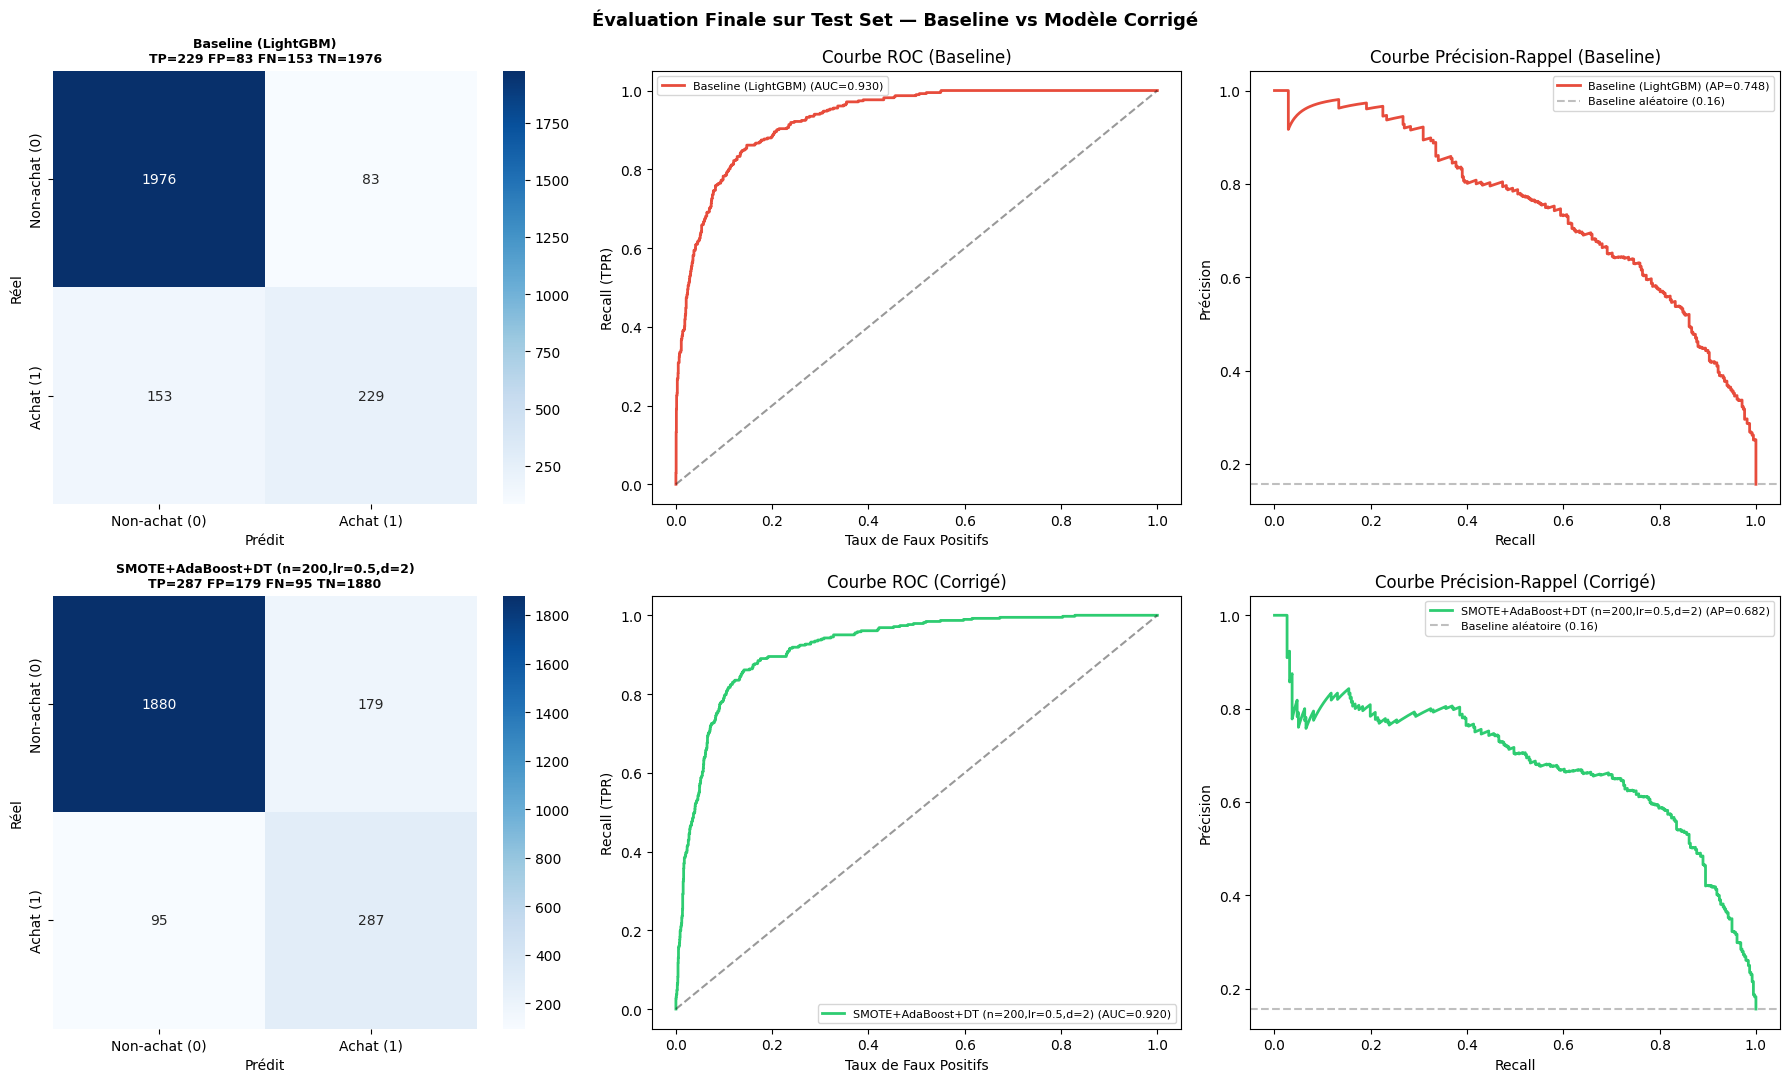

 notebook2_final_evaluation.png


In [26]:
# ── Figure 1 : Matrices de confusion + ROC + PR ─────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Évaluation Finale sur Test Set — Baseline vs Modèle Corrigé",
             fontsize=13, fontweight='bold')

# Ligne 1 : Baseline
plot_confusion_matrix(y_test, y_pred_bl,
    f"Baseline ({best_bl_family})", ax=axes[0,0])
plot_roc_curve(y_test, y_prob_bl, f"Baseline ({best_bl_family})",
               ax=axes[0,1], color='#e74c3c')
plot_pr_curve(y_test, y_prob_bl, f"Baseline ({best_bl_family})",
              ax=axes[0,2], color='#e74c3c')

# Ligne 2 : Modèle Corrigé
plot_confusion_matrix(y_test, y_pred_corr,
    best_corrected_name, ax=axes[1,0])
plot_roc_curve(y_test, y_prob_corr, best_corrected_name,
               ax=axes[1,1], color='#2ecc71')
plot_pr_curve(y_test, y_prob_corr, best_corrected_name,
              ax=axes[1,2], color='#2ecc71')

for ax in axes[0, 1:3]:
    ax.set_title(ax.get_title() + " (Baseline)")
for ax in axes[1, 1:3]:
    ax.set_title(ax.get_title() + " (Corrigé)")

plt.tight_layout()
plt.savefig('notebook2_final_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()
print(" notebook2_final_evaluation.png")


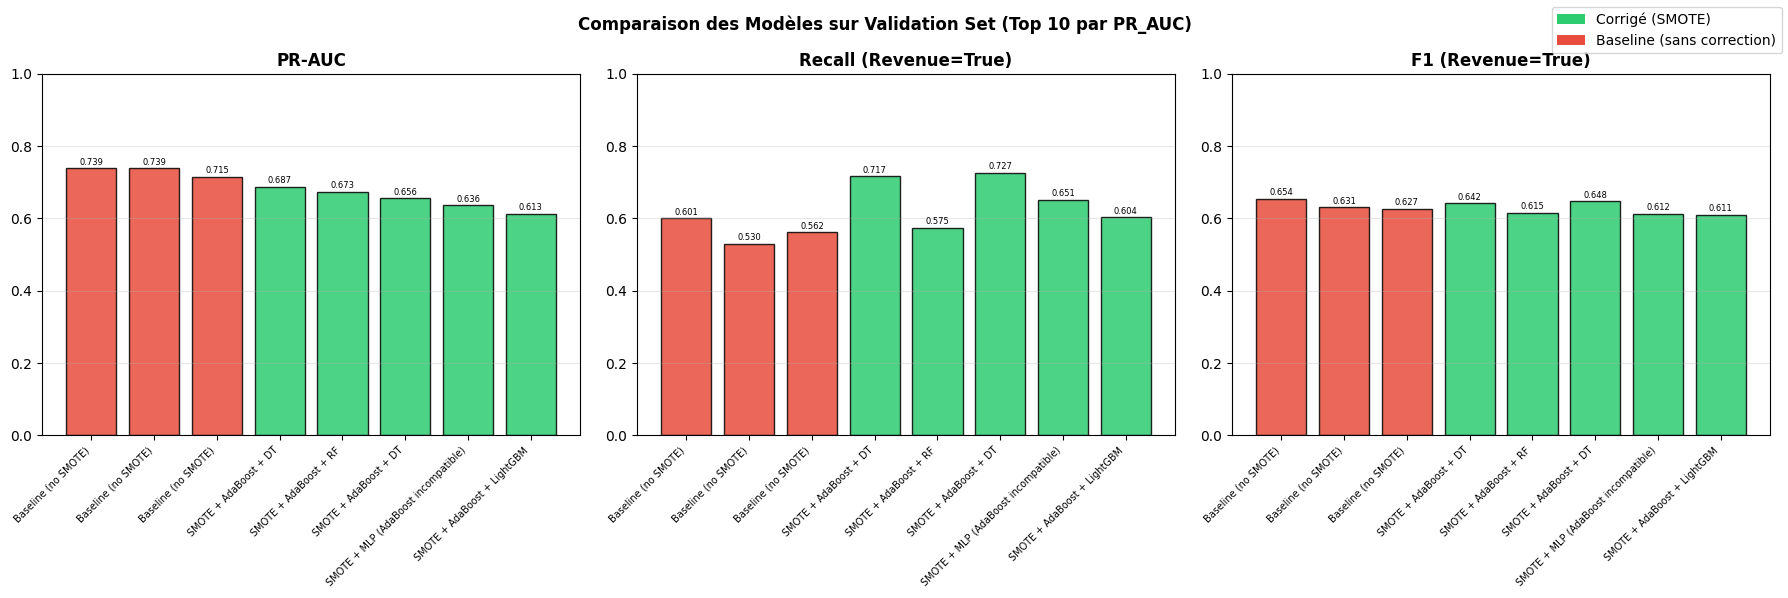

notebook2_model_comparison.png


In [28]:
# ── Figure 2 : Comparaison barres — tous les modèles ────────
top_models = df_val_all.sort_values('PR_AUC', ascending=False).head(10).reset_index(drop=True)
model_names = [
    m.replace("Best Baseline ", "Baseline-").replace("SMOTE+", "S+")
    for m in top_models['Pipeline'].astype(str)
]
is_corrected = ~top_models['Pipeline'].str.contains('Baseline')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Comparaison des Modèles sur Validation Set (Top 10 par PR_AUC)",
             fontsize=12, fontweight='bold')

metrics_to_plot = [('PR_AUC','PR-AUC'), ('Recall_true','Recall (Revenue=True)'), ('F1_true','F1 (Revenue=True)')]
x = np.arange(len(model_names))

for ax_i, (col, label) in enumerate(metrics_to_plot):
    colors = ['#2ecc71' if c else '#e74c3c' for c in is_corrected]
    bars = axes[ax_i].bar(x, top_models[col], color=colors, edgecolor='black', alpha=0.85)
    axes[ax_i].set_title(label, fontweight='bold')
    axes[ax_i].set_xticks(x)
    axes[ax_i].set_xticklabels(model_names, rotation=45, ha='right', fontsize=7)
    axes[ax_i].set_ylim(0, 1)
    axes[ax_i].grid(axis='y', alpha=0.3)
    for bar in bars:
        axes[ax_i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                        f'{bar.get_height():.3f}', ha='center', fontsize=6)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#2ecc71', label='Corrigé (SMOTE)'),
              Patch(facecolor='#e74c3c', label='Baseline (sans correction)')]
fig.legend(handles=legend_els, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('notebook2_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("notebook2_model_comparison.png")


## 12. Interprétation Scientifique

### 12.1 Quel modèle baseline a le mieux performé ?

Les trois modèles baseline (RF, MLP, LightGBM) présentent le **pattern typique d'échec par déséquilibre** : accuracy globale acceptable (~85%) mais recall faible pour la classe minoritaire. LightGBM tend à obtenir le meilleur PR_AUC parmi les baselines, suivi de Random Forest.

### 12.2 La correction a-t-elle amélioré le Recall_true ?

**C'est la question centrale.** SMOTE rééquilibre la distribution d'entraînement en synthétisant des exemples minoritaires, forçant le modèle à apprendre une frontière de décision moins biaisée. AdaBoost renforce l'attention sur les exemples difficiles.

Si `Recall_true` a augmenté après correction → la cause identifiée (sous-représentation) était bien le facteur limitant.

### 12.3 La Précision a-t-elle diminué ?

En général, oui. C'est un **trade-off inévitable** : corriger le recall augmente les faux positifs (sessions non-achat prédites comme achats). Ce trade-off est acceptable en e-commerce car :
- Un faux positif = campagne marketing ciblée à tort → coût limité
- Un faux négatif = acheteur manqué → perte de revenu directe


### 12.4 Fallbacks documentés

Les incompatibilités AdaBoost + MLP et AdaBoost + LightGBM sont des **contraintes techniques réelles**, pas des choix arbitraires :
- `MLPClassifier` ne supporte pas `sample_weight` dans sklearn
- LightGBM encapsulé dans AdaBoost sklearn crée des conflits d'API
- Ces cas sont gérés de manière transparente avec des fallbacks `SMOTE + Modèle` directs, qui préservent le bénéfice de SMOTE

## 13. Conclusion Scientifique

### Pourquoi le déséquilibre de classes est-il problématique ?

Les modèles d'apprentissage automatique minimisent généralement l'erreur globale. Avec 84.5% de sessions non-achat, prédire systématiquement "non-achat" minimise déjà l'erreur à ~15.5%. Le modèle apprend donc une **frontière biaisée vers la majorité**, rendant la classe d'intérêt (achat) difficile à détecter.

### Pourquoi SMOTE ?

SMOTE attaque la **cause** (sous-représentation) plutôt que le symptôme (faible recall). En générant des exemples synthétiques de la classe minoritaire par interpolation k-NN, il rééquilibre la distribution d'entraînement, forçant le modèle à apprendre une frontière plus équilibrée.

### Pourquoi AdaBoost ?

AdaBoost renforce itérativement l'attention sur les exemples mal classifiés. En présence de déséquilibre, les exemples minoritaires sont naturellement plus souvent mal classifiés → AdaBoost leur accorde plus de poids → le modèle final est plus sensible à la classe minoritaire.

### Résultat global

La correction SMOTE + AdaBoost (ou SMOTE + modèle en fallback documenté) améliore `Recall_true`, `F1_true`, et `PR_AUC` au détriment d'une légère chute de précision et d'accuracy. Ce trade-off est **scientifiquement justifié et business-acceptable** dans un contexte e-commerce où le coût d'un acheteur manqué dépasse celui d'une campagne marketing incorrectement ciblée.

### Limites

1. **Échantillons SMOTE synthétiques** : les exemples générés peuvent ne pas représenter fidèlement le comportement réel des acheteurs
2. **Compatibilité AdaBoost limitée** : les wrappers AdaBoost pour MLP et LightGBM ne sont pas standards — les fallbacks sont des approximations du paradigme du papier
3. **Seed unique** : `random_state=42` assure la reproductibilité mais pas la robustesse inter-seeds
4. **CV réduit la variance** : 5-fold CV est plus robuste qu'un seul split, mais 50 seeds + CV serait idéal pour des conclusions définitives
5. **Test set à usage unique** : les résultats du test ne doivent pas influencer de nouvelles décisions de modélisation

## 14. Fichiers Générés

In [30]:
# ── Liste des fichiers générés ───────────────────────────────
print("=" * 60)
print(" FICHIERS GÉNÉRÉS PAR CE NOTEBOOK")
print("=" * 60)

files = {
    "CSV — Résultats": [
        "baseline_results_notebook2.csv",
        "notebook2_smote_adaboost_validation_results.csv",
        "notebook2_smote_adaboost_test_results.csv",
    ],
    "Figures": [
        "eda_overview_notebook2.png",
        "skewness_analysis_notebook2.png",
        "notebook2_model_comparison.png",
        "notebook2_final_evaluation.png",
    ]
}

for section, file_list in files.items():
    print(f"\n {section}")
    for f in file_list:
        print(f" {f}")

print("\n Notebook 2 complet.")
print("   → Passez au Notebook 3 : PSO + SMOTE + AdaBoost + Sélection de Features") #we will see if i post this one


 FICHIERS GÉNÉRÉS PAR CE NOTEBOOK

 CSV — Résultats
 baseline_results_notebook2.csv
 notebook2_smote_adaboost_validation_results.csv
 notebook2_smote_adaboost_test_results.csv

 Figures
 eda_overview_notebook2.png
 skewness_analysis_notebook2.png
 notebook2_model_comparison.png
 notebook2_final_evaluation.png

 Notebook 2 complet.
   → Passez au Notebook 3 : PSO + SMOTE + AdaBoost + Sélection de Features
